<a href="https://colab.research.google.com/github/Gr1lledChee5e/RegressionAnalysis/blob/main/ARIMAX___Dynamic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Packages

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.deterministic import DeterministicProcess

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.api import VAR # Vector Autoregression
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import boxcox_normmax
from statsmodels.stats.diagnostic import acorr_ljungbox

# Helper Functions

## accuracy

In [ ]:
def accuracy(y_observed, y_forecast):
  mae = np.mean(np.abs(y_observed - y_forecast))
  rmse = np.sqrt(np.mean((y_observed - y_forecast)**2))
  mape = np.mean(np.abs((y_observed - y_forecast) / y_observed)) * 100
  print(f'''
    MAE: {mae}
    RMSE: {rmse}
    MAPE: {mape}
  ''')

## acf_plots

In [ ]:
def acf_plots(y, lags=20, pacf_method="ywm"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    y = y.dropna()
    plot_acf(y, lags=lags, ax=axes[0])
    plot_pacf(y, lags=lags,  method=pacf_method, ax=axes[1])
    axes[0].set_title("ACF")
    axes[1].set_title("PACF")
    axes[0].set_xlim((0, lags))
    axes[1].set_xlim((0, lags))
    plt.tight_layout()
    return fig.show()

## eacf_plot

In [ ]:
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import acf

def eacf_plot(y, max_p=4, max_q=4):
    y = y.dropna()
    y = np.asarray(y)
    n = len(y)
    crit = 2 / np.sqrt(n)  # approx 95% CI

    table = np.empty((max_p + 1, max_q + 1), dtype=object)

    for p in range(max_p + 1):
        if p == 0:
            resid = y - y.mean()
        else:
            ar = AutoReg(y, lags=p, old_names=False).fit()
            resid = ar.resid

        r = acf(resid, nlags=max_q, fft=False)

        for q in range(max_q + 1):
            table[p, q] = "o" if abs(r[q]) < crit else "x"

    return table

## lb_plot

Ljung-Box P-Values

Used to check residuals for remaining autocorrelation. Plot returns p-values for testing for autocorrelation up to each lag. We want to see high p-values, which would indicate that there is no remaining autocorrelation in the series (because we captured it in our model).



In [ ]:
def lb_plot(model_fit):
  results = acorr_ljungbox(model_fit.resid)
  lags = results.index + 1
  plt.figure(figsize=(12,6))
  plt.scatter(x=lags, y=results['lb_pvalue'])
  plt.axhline(y=0.05, color='red', linestyle='--')
  plt.ylim(0, 1)
  plt.show()

## tslm_cv

In [ ]:
def tslm_cv(
    y: pd.Series,
    h: int,
    initial: int,
    step: int = 1,
    trend_order: int=0,
    seasonal: bool=False,
    period: int=12
):

    n = len(y)

    rows = []
    fold = 0

    for train_end in range(initial, n - h + 1, step):
        fold += 1
        y_train = y.iloc[:train_end]
        y_test  = y.iloc[train_end:train_end + h]

        # Build deterministic terms on training index
        dp = DeterministicProcess(
            index=y_train.index,
            constant=True,
            order=trend_order,
            seasonal=seasonal,
            period=period
        )

        X_train = dp.in_sample()
        model = sm.OLS(y_train, X_train).fit()

        # Forecast next h periods
        X_fut = dp.out_of_sample(steps=h)
        y_hat = model.predict(X_fut)
        y_hat = pd.Series(y_hat, index=X_fut.index)

        # Align with actual y_test (should match if freq is consistent)
        y_hat = y_hat.reindex(y_test.index)

        fold_df = pd.DataFrame({
            "fold": fold,
            "cutoff": y_train.index[-1],
            "h": np.arange(1, h + 1),
            "y": y_test.values,
            "y_hat": y_hat.values
        }, index=y_test.index)

        rows.append(fold_df)

    cv_df = pd.concat(rows).sort_index()

    # Overall metrics
    err = cv_df["y"] - cv_df["y_hat"]
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))

    denom = np.where(cv_df["y"].values == 0, np.nan, np.abs(cv_df["y"].values))
    mape = float(np.nanmean(np.abs(err.values) / denom) * 100)

    metrics = {"MAE": mae, "RMSE": rmse, "MAPE%": mape}
    #return cv_df, metrics
    return metrics

## arima_cv

In [ ]:
def arima_cv(
    y: pd.Series,
    h: int=1,
    initial: int=24,
    step: int=1,
    p: int=0,
    d: int=0,
    q: int=0,
    P: int=0,
    D: int=0,
    Q: int=0,
    s: int=0,
    trend: str='t'
):

    n = len(y)

    rows = []
    fold = 0

    for train_end in range(initial, n - h + 1, step):
        fold += 1
        y_train = y.iloc[:train_end]
        y_test  = y.iloc[train_end:train_end + h]

        # ARIMA Model

        model = ARIMA(y_train, order=(p, d, q), seasonal_order=(P, D, Q, s), trend=trend).fit()

        # Forecast next h periods
        y_hat = model.forecast(steps = h)

        # Align with actual y_test (should match if freq is consistent)
        y_hat = y_hat.reindex(y_test.index)
        fold_df = pd.DataFrame({
            "fold": fold,
            "cutoff": y_train.index[-1],
            "h": np.arange(1, h + 1),
            "y": y_test.values,
            "y_hat": y_hat.values
        }, index=y_test.index)

        rows.append(fold_df)

    cv_df = pd.concat(rows).sort_index()

    # Overall metrics
    err = cv_df["y"] - cv_df["y_hat"]
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))

    denom = np.where(cv_df["y"].values == 0, np.nan, np.abs(cv_df["y"].values))
    mape = float(np.nanmean(np.abs(err.values) / denom) * 100)

    metrics = {"MAE": mae, "RMSE": rmse, "MAPE%": mape}
    #return cv_df, metrics
    return metrics

## arimax_cv

In [ ]:
def arimax_cv(
    y: pd.Series,
    exog: pd.Series,
    h: int=1,
    initial: int=24,
    step: int=1,
    p: int=0,
    d: int=0,
    q: int=0,
    P: int=0,
    D: int=0,
    Q: int=0,
    s: int=0,
    trend: str='t'
):

    n = len(y)

    rows = []
    fold = 0

    for train_end in range(initial, n - h + 1, step):
        fold += 1
        y_train = y.iloc[:train_end]
        y_test  = y.iloc[train_end:train_end + h]
        X_train = exog.iloc[:train_end]
        X_test  = exog.iloc[train_end:train_end + h]

        # ARIMA Model

        model = ARIMA(y_train, exog=X_train, order=(p, d, q), seasonal_order=(P, D, Q, s), trend=trend).fit()

        # Forecast next h periods
        y_hat = model.forecast(steps = h, exog=X_test)

        # Align with actual y_test (should match if freq is consistent)
        y_hat = y_hat.reindex(y_test.index)
        fold_df = pd.DataFrame({
            "fold": fold,
            "cutoff": y_train.index[-1],
            "h": np.arange(1, h + 1),
            "y": y_test.values,
            "y_hat": y_hat.values
        }, index=y_test.index)

        rows.append(fold_df)

    cv_df = pd.concat(rows).sort_index()

    # Overall metrics
    err = cv_df["y"] - cv_df["y_hat"]
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))

    denom = np.where(cv_df["y"].values == 0, np.nan, np.abs(cv_df["y"].values))
    mape = float(np.nanmean(np.abs(err.values) / denom) * 100)

    metrics = {"MAE": mae, "RMSE": rmse, "MAPE%": mape}
    #return cv_df, metrics
    return metrics

## TO DO: Add VAR

# Section I - Including an intercept in ARIMA Model

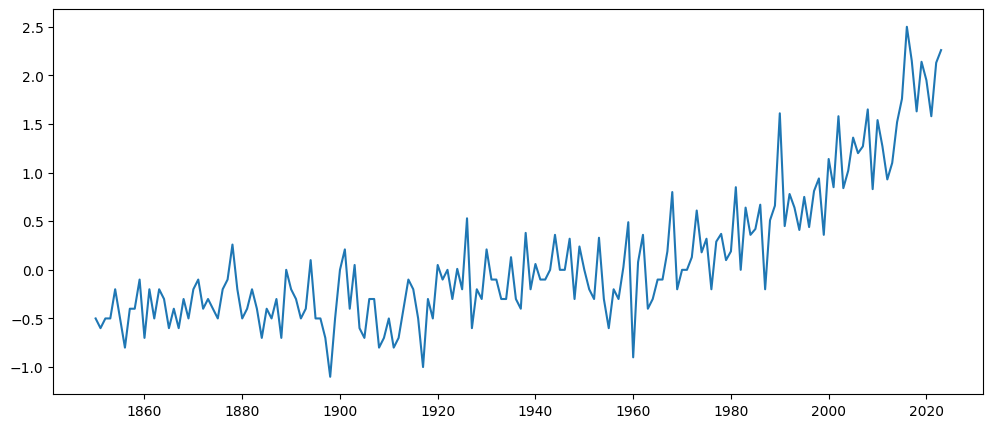

In [ ]:
# Global Temperature Deviations Data (From Day 6)
temps = pd.read_csv('https://dxl-datasets.s3.us-east-1.amazonaws.com/mas640/tsa/global_temps.csv')
temps.head()
temps['year'] = pd.to_datetime(temps['year'].astype(str))
temps = temps.set_index('year')
y = temps['temp_deviation'].asfreq('YS')

plt.figure(figsize=(12,5))
plt.plot(y)
plt.show()

In [ ]:
# Notice that the mean of the differenced series in non-zero
#  This means we need an INTERCEPT in the regression model


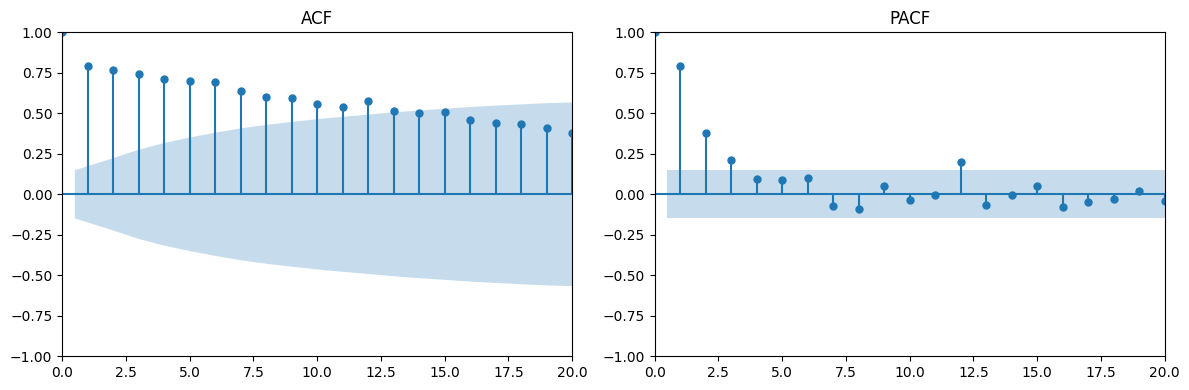

In [ ]:
# acf plots shows clear MA(1) pattern
acf_plots(y)


In [ ]:
# Note the intercept in model (listed as x1 in regression summary)
m_arima = ARIMA(y, order=(0,1,1), trend='n').fit()
print(m_arima.summary())


                               SARIMAX Results                                
Dep. Variable:         temp_deviation   No. Observations:                  174
Model:                 ARIMA(0, 1, 1)   Log Likelihood                 -57.573
Date:                Tue, 03 Feb 2026   AIC                            119.146
Time:                        13:16:01   BIC                            125.452
Sample:                    01-01-1850   HQIC                           121.704
                         - 01-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7545      0.051    -14.752      0.000      -0.855      -0.654
sigma2         0.1134      0.011     10.587      0.000       0.092       0.134
Ljung-Box (L1) (Q):                   1.13   Jarque-

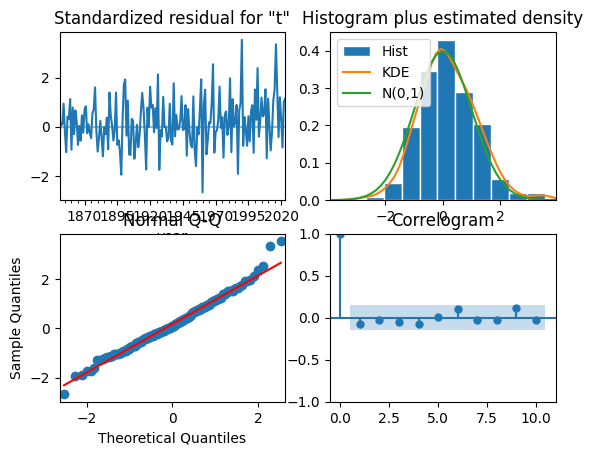

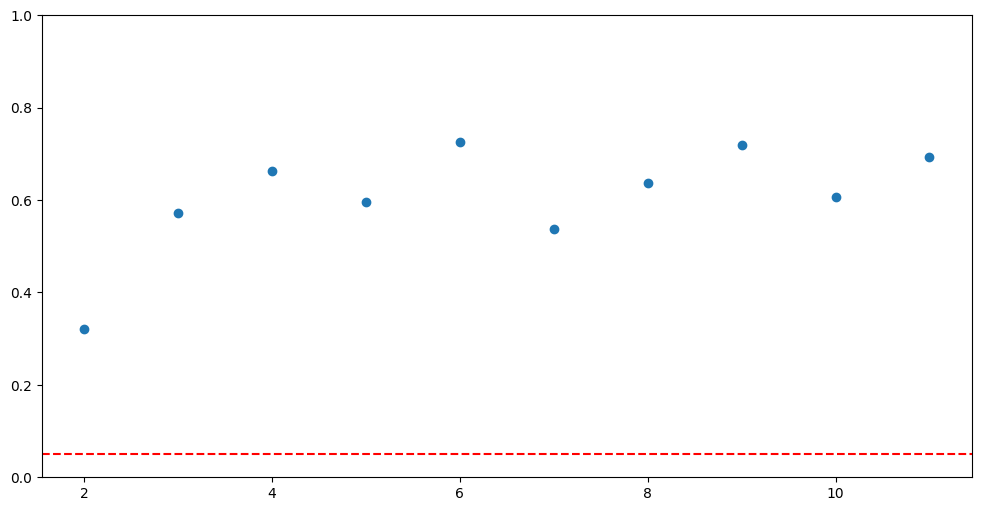

In [ ]:
# Residual diagnostics look good
#   1) Random / constant variance
#   2) Approximately normally distributed
#   3) No remaining autocorrelation
#   4) Plot of Ljung-Box pvalues confirms no remaining autocorrelation considering various lags
# You would normally STILL spend a minute or so "overfitting" -> add an MA, test it, add an AR, test, add both, etc etc until you find your preferred model
m_arima.plot_diagnostics()
plt.show()
lb_plot(m_arima)


In [ ]:
# Cross validated in Day 6, so skip that here
cv = arima_cv(y, h=12, initial=24, step=1)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

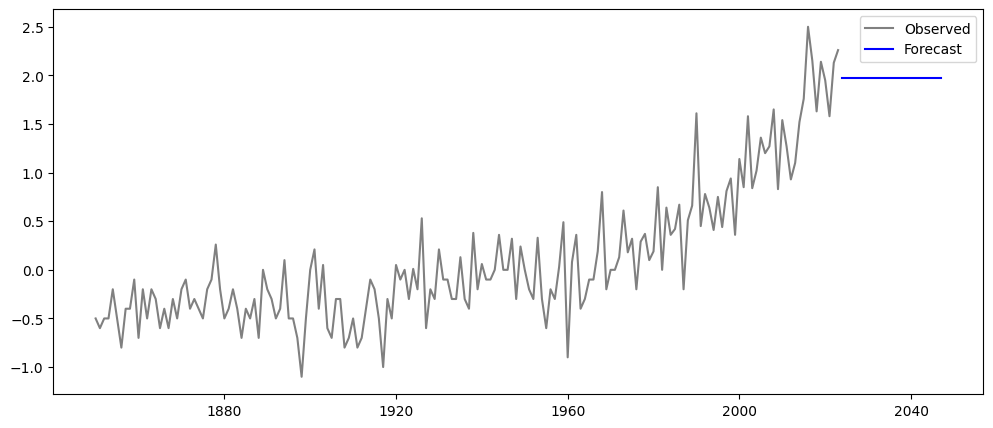

In [ ]:
# Forecast and Plot


# I'm forecasting WAY out here just to highlight the difference in trend / no-trend
y_fc = m_arima.forecast(steps=24)

plt.figure(figsize=(12, 5))
plt.plot(y, label='Observed', color='grey')
plt.plot(y_fc, label='Forecast', color='blue')
plt.legend()
plt.show()

# Section II - Recap

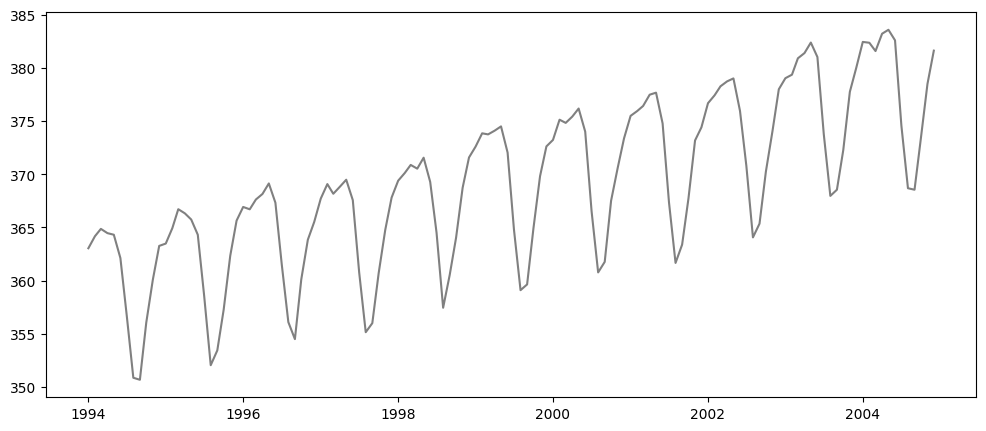

In [ ]:
co2 = pd.read_csv('https://dxl-datasets.s3.us-east-1.amazonaws.com/mas640/tsa/co2.csv')
co2['date'] = pd.to_datetime(co2['date'])
co2 = co2.set_index('date')
y = co2['co2'].asfreq('MS')

plt.figure(figsize=(12, 5))
plt.plot(y, color='grey')
plt.show()

### TSLM

In [ ]:
dp = DeterministicProcess(
    index=y.index,
    constant=True,
    order= 0,
    seasonal= True,
    period=12
)

X = dp.in_sample()
m_tslm = sm.OLS(y, X).fit()
print(m_tslm.summary())

                            OLS Regression Results                            
Dep. Variable:                    co2   R-squared:                       0.422
Model:                            OLS   Adj. R-squared:                  0.369
Method:                 Least Squares   F-statistic:                     7.958
Date:                Tue, 03 Feb 2026   Prob (F-statistic):           2.84e-10
Time:                        13:26:19   Log-Likelihood:                -420.32
No. Observations:                 132   AIC:                             864.6
Df Residuals:                     120   BIC:                             899.2
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        371.8236      1.848    201.215      0.0

In [ ]:
# Look at remaining autocorrelation in residuals?
auto_corr = acorr_ljungbox(m_tslm.resid)
auto_corr

,lb_stat,lb_pvalue
1,126.912073,1.941891e-29
2,249.127895,7.990334e-55
3,367.114545,2.935003e-79
4,480.776396,9.626051e-103
5,589.305559,4.134876e-125
6,692.688522,2.317888e-146
7,790.599672,1.981305e-166
8,883.920451,1.659826e-185
9,971.886822,1.986079e-203
10,1056.020977,1.590793e-220


### ARIMA

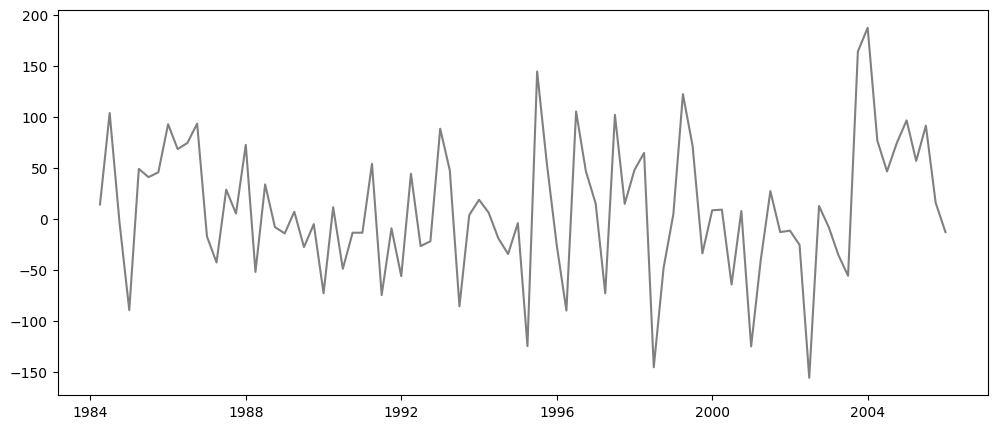

In [ ]:
# Nonseasonal + Seasonal diff seems to work well
plt.figure(figsize=(12, 5))
plt.plot(y.diff(12), color='grey')
plt.show()

                                    SARIMAX Results                                     
Dep. Variable:                            Sales   No. Observations:                  100
Model:             ARIMA(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -470.225
Date:                          Tue, 03 Feb 2026   AIC                            946.449
Time:                                  14:29:21   BIC                            953.847
Sample:                              03-31-1981   HQIC                           949.428
                                   - 12-31-2005                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8794      0.070    -12.507      0.000      -1.017      -0.742
ma.S.L12      -0.9945      7.548     -0.132      0.

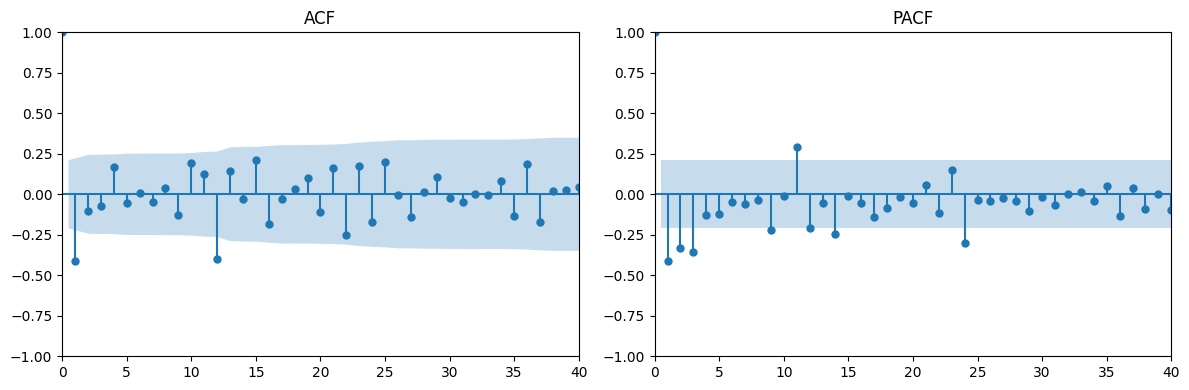

In [ ]:
# Nonseasonal ... [why?]
# Seasonal ... [why?]
acf_plots(y.diff().diff(12),lags=40)


m_arima = ARIMA(y, order = (0,1,1), seasonal_order=(0,1,1,12)).fit()
print(m_arima.summary())

In [ ]:
m_arima = ARIMA(y, order=(0,1,0), seasonal_order=(0,1,0,12)).fit()
print(m_arima.summary())

                                    SARIMAX Results                                     
Dep. Variable:                              co2   No. Observations:                  132
Model:             ARIMA(0, 1, 0)x(0, 1, 0, 12)   Log Likelihood                -185.725
Date:                          Tue, 03 Feb 2026   AIC                            373.450
Time:                                  13:33:18   BIC                            376.229
Sample:                              01-01-1994   HQIC                           374.579
                                   - 12-01-2004                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         1.3278      0.184      7.234      0.000       0.968       1.688
Ljung-Box (L1) (Q):                  35.09   Jarque

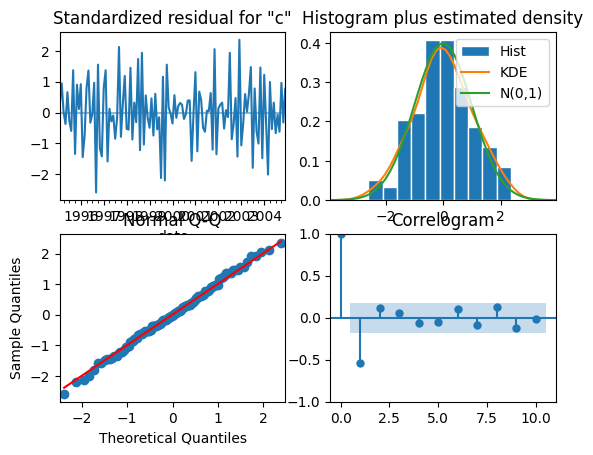

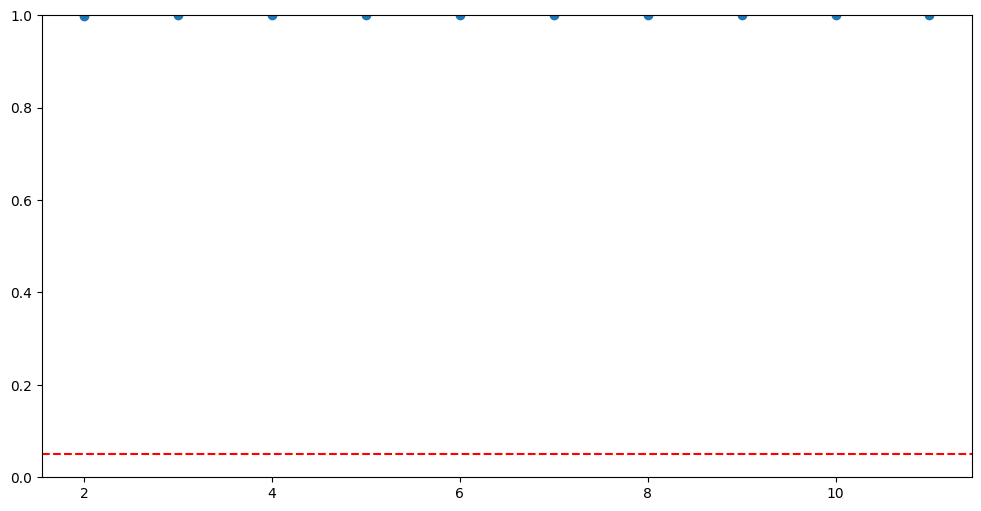

In [ ]:
# Residual diagnostics?
m_arima.plot_diagnostics()
plt.show()
lb_plot(m_arima)

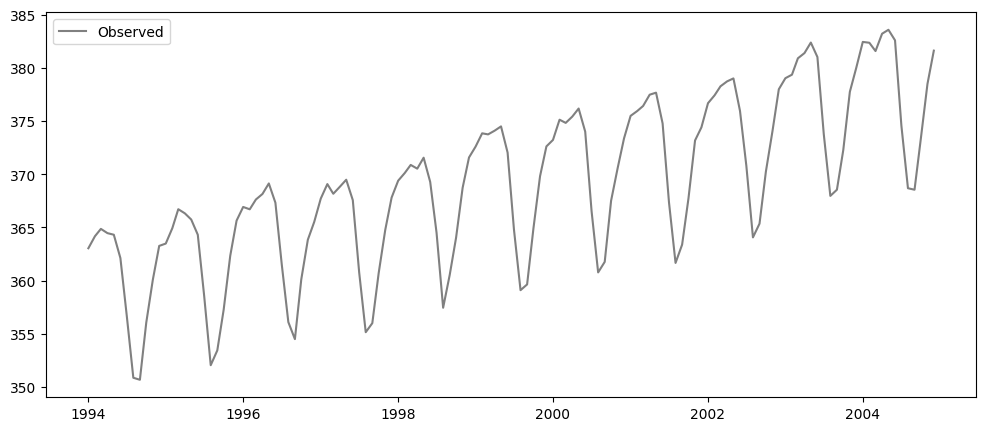

In [ ]:
# Fitted Values (note that ARIMA needs "burn-in" period. More parameters = longer period, seasonal parameters = longer period)

plt.figure(figsize=(12, 5))
plt.plot(y, color='grey', label='Observed')
plt.legend()
plt.show()


In [ ]:
# Careful when calculating cross validation metrics
print('Arima: ', np.sqrt(np.mean(m_arima.resid**2)))
print('TSLM: ', np.sqrt(np.mean(m_tslm.resid**2)))

Arima:  35.35107408315692
TSLM:  5.843549373775032


In [ ]:
# Forecast (forecasting from ARIMA to keep it simple here, but add TSLM for practice!)
y_fc = m_arima.forecast(steps=21*12+1)

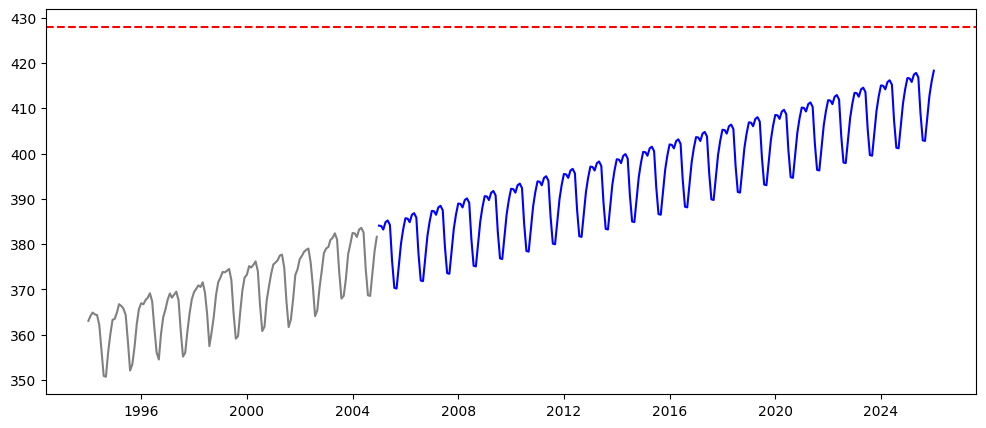

In [ ]:
# Google: CO2 PPM Today, Answer: 428
plt.figure(figsize=(12, 5))
plt.plot(y, color='grey')
plt.plot(y_fc, color='blue')
plt.axhline(y = 428, color='red', linestyle='--')
plt.show()

# Section III - ARIMAX

## Data - Advertising Budget and Sales

In [ ]:
# Works well with a sesaonal diff
# Set up for "what if" under ArimaX
ads = pd.read_csv('https://dxl-datasets.s3.amazonaws.com/mas646/advertising_and_sales.csv')

ads['Month'] = pd.to_datetime(ads['Month'], format="%b-%y") + pd.offsets.MonthEnd(0)
ads = ads.set_index('Month')

y = ads['Sales'].asfreq('QE')
X = ads['AdBudget'].asfreq('QE')
X = sm.add_constant(X)

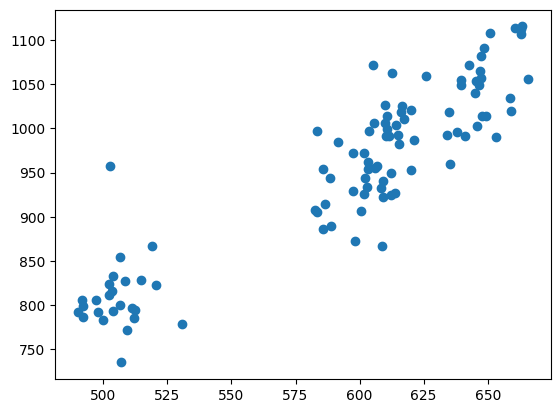

In [ ]:
plt.scatter(x=ads['AdBudget'], y=ads['Sales'])
plt.show()

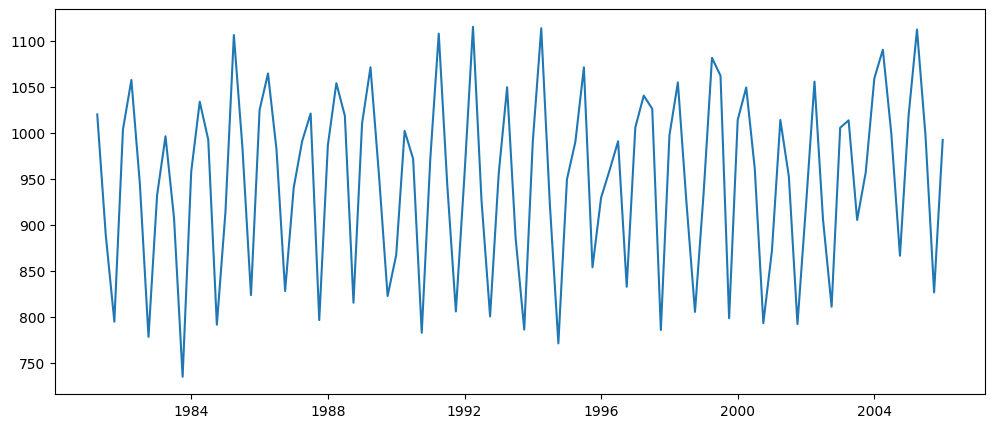

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(y)
plt.show()

In [ ]:
# Based on patterns, you have OPTIONS!
#   1) Linear regression of Sales ~ Budget
#   2) TSLM of Sales ~ Trend + Season
#   3) TSLM of Sales ~ Trend + Season + Budget [Skip this here, more common to handle seasonality in ARIMA portion if wanting to incorporate an X var]
#   4) ARIMA on Sales
#   5) ARIMAX on Sales using Budget [ 1st Regression from 1) then ARIMA on residuals from that model]

In [ ]:
dp_tslm = DeterministicProcess(
    index=y.index,
    constant=True,
    order=1, # Linear trend
    seasonal=True,
    period=4 # Quarterly data
)
X_tslm = dp_tslm.in_sample()
m_tslm_sales = sm.OLS(y, X_tslm).fit()
print(m_tslm_sales.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.797
Model:                            OLS   Adj. R-squared:                  0.788
Method:                 Least Squares   F-statistic:                     93.27
Date:                Tue, 03 Feb 2026   Prob (F-statistic):           4.92e-32
Time:                        13:37:53   Log-Likelihood:                -520.41
No. Observations:                 100   AIC:                             1051.
Df Residuals:                      95   BIC:                             1064.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1033.2448     11.857     87.140      0.0

In [ ]:
model5 = sm.OLS(y,X).fit()
print(model5.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     458.9
Date:                Tue, 03 Feb 2026   Prob (F-statistic):           9.37e-39
Time:                        13:36:00   Log-Likelihood:                -513.27
No. Observations:                 100   AIC:                             1031.
Df Residuals:                      98   BIC:                             1036.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -22.7772     45.538     -0.500      0.6

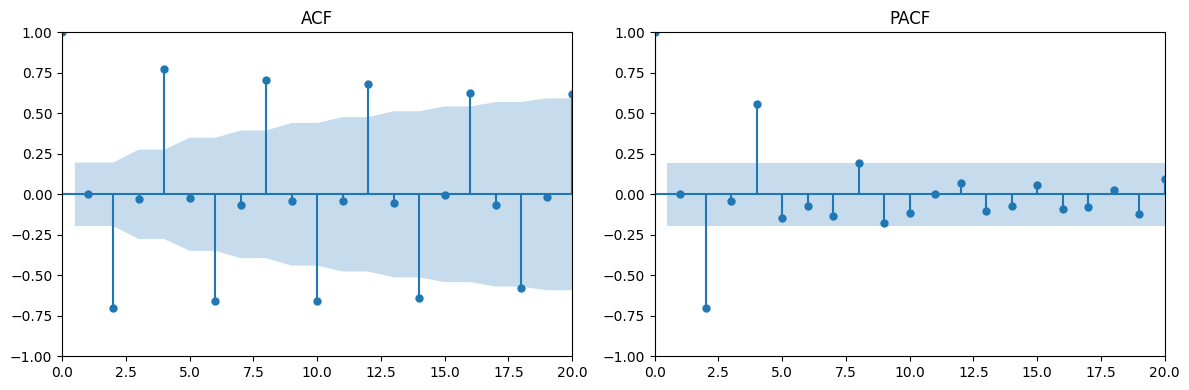

In [ ]:
acf_plots(y, lags=20, pacf_method="ywm")

                                    SARIMAX Results                                    
Dep. Variable:                           Sales   No. Observations:                  100
Model:             ARIMA(0, 1, 0)x(0, 1, 0, 4)   Log Likelihood                -550.210
Date:                         Tue, 03 Feb 2026   AIC                           1102.421
Time:                                 13:38:40   BIC                           1104.975
Sample:                             03-31-1981   HQIC                          1103.453
                                  - 12-31-2005                                         
Covariance Type:                           opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      6282.0360    849.417      7.396      0.000    4617.210    7946.862
Ljung-Box (L1) (Q):                  15.15   Jarque-Bera (J

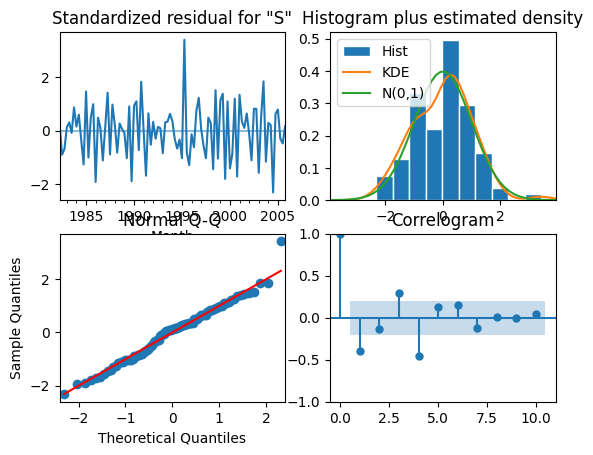

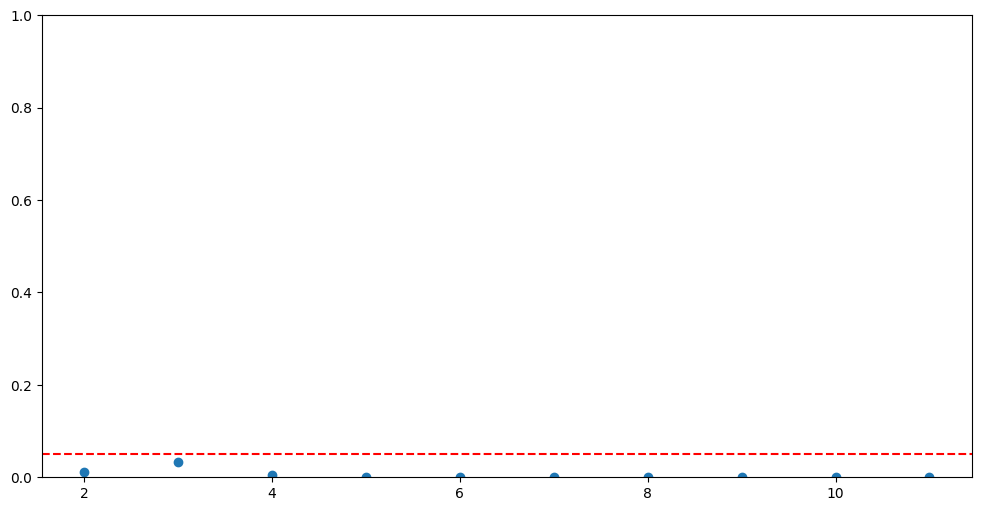

In [ ]:
m_arima_sales = ARIMA(y, order=(0,1,0), seasonal_order=(0,1,0,4)).fit()
print(m_arima_sales.summary())

m_arima_sales.plot_diagnostics()
plt.show()
lb_plot(m_arima_sales)

--- Step 1: Fit OLS model of Sales on Budget ---
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     458.9
Date:                Tue, 03 Feb 2026   Prob (F-statistic):           9.37e-39
Time:                        13:41:33   Log-Likelihood:                -513.27
No. Observations:                 100   AIC:                             1031.
Df Residuals:                      98   BIC:                             1036.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
con

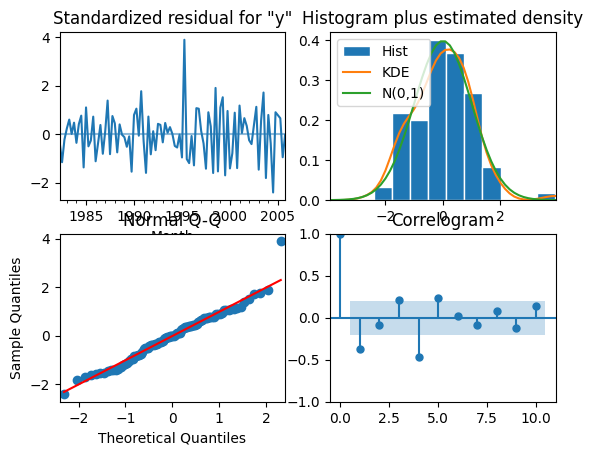

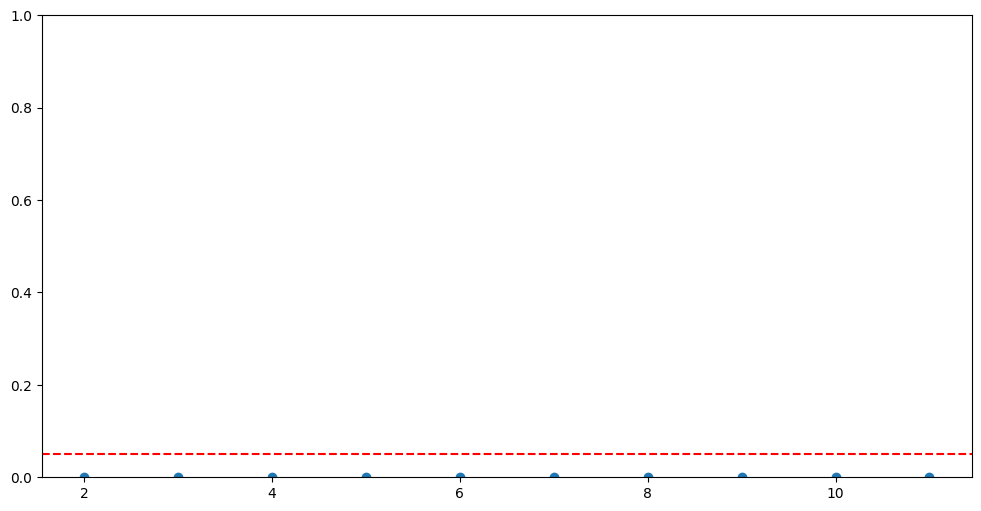

In [ ]:
print('--- Step 1: Fit OLS model of Sales on Budget ---')
m_ols_sales_budget = sm.OLS(y, X).fit()
print(m_ols_sales_budget.summary())

print('\n--- Step 2: Extract residuals from OLS model ---')
ols_residuals = m_ols_sales_budget.resid
print(f"First 5 OLS residuals: {ols_residuals.head().tolist()}")

print('\n--- Step 3, 4, 5, 6: Apply ARIMA to residuals, print summary, plot diagnostics, and Ljung-Box p-values ---')
m_arima_ols_residuals = ARIMA(ols_residuals, order=(0,1,0), seasonal_order=(0,1,0,4)).fit()
print(m_arima_ols_residuals.summary())

m_arima_ols_residuals.plot_diagnostics()
plt.show()
lb_plot(m_arima_ols_residuals)

In [ ]:
print('ARima:', np.sqrt(np.mean(m_arima_sales.resid[13:]**2)))
print('tslm:', np.sqrt(np.mean(m_tslm_sales.resid[13:]**2)))

ARima: 81.83952126802511
tslm: 45.33538258864741


$$$$$$$$$$$$$

In [ ]:
ads = pd.read_csv('https://dxl-datasets.s3.amazonaws.com/mas646/advertising_and_sales.csv')
ads['Month'] = pd.to_datetime(ads['Month'], format="%b-%y") + pd.offsets.MonthEnd(0)
ads = ads.set_index('Month')

y = ads['Sales'].asfreq('QE')
budget = ads['AdBudget'].asfreq('QE')
X = sm.add_constant(budget)

In [ ]:
m_lin = sm.OLS(y, X).fit()
print(m_lin.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     458.9
Date:                Tue, 03 Feb 2026   Prob (F-statistic):           9.37e-39
Time:                        15:04:04   Log-Likelihood:                -513.27
No. Observations:                 100   AIC:                             1031.
Df Residuals:                      98   BIC:                             1036.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -22.7772     45.538     -0.500      0.6

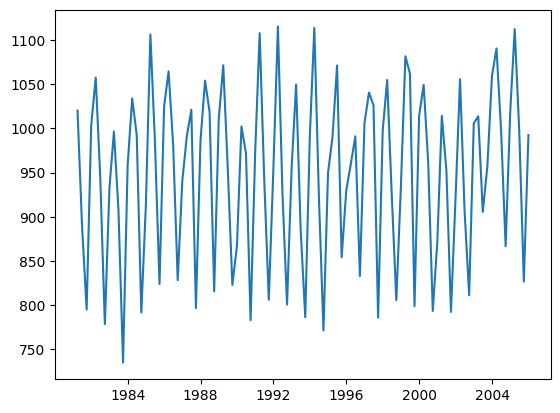

In [ ]:
plt.plot(y)

In [ ]:
#tslm using sales ~ trend + season
dp = DeterministicProcess(
    index = y.index,
    constant = True,
    order = 1,
    seasonal = True
)

X_tslm = dp_tslm.in_sample()
m_tslm_sales = sm.OLS(y, X_tslm).fit()
print(m_tslm_sales.summary())


                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.797
Model:                            OLS   Adj. R-squared:                  0.788
Method:                 Least Squares   F-statistic:                     93.27
Date:                Tue, 03 Feb 2026   Prob (F-statistic):           4.92e-32
Time:                        15:08:24   Log-Likelihood:                -520.41
No. Observations:                 100   AIC:                             1051.
Df Residuals:                      95   BIC:                             1064.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1033.2448     11.857     87.140      0.0

## Data - US Consumption and Income

In [ ]:
us_change = pd.read_csv('https://dxl-datasets.s3.us-east-1.amazonaws.com/mas640/fppy/US_change.csv')
us_change.head()

# ARIMA(X) -> Both AR(3) pass assumptions (ARIMA wins, then ARIMAX, then TSLM)
# Intro VAR here as well

# Section IV - Vector Autoregression (VAR)

## Data - US Economic Indicators

In [ ]:
us_change_wide = pd.read_csv('https://dxl-datasets.s3.amazonaws.com/data/us_change.csv')
us_change_wide['Quarter'] = pd.PeriodIndex(us_change_wide['Quarter'].str.replace(' ', ''), freq="Q").to_timestamp()
us_change_wide = us_change_wide.set_index('Quarter')
us_change_wide = us_change_wide.asfreq('QS')
us_change_wide.head()

```markdown
# Time Series Analysis Notebook

This notebook explores various time series forecasting models and diagnostic tools using Python. It covers the implementation and application of:

-   **ARIMA (AutoRegressive Integrated Moving Average)**: For modeling univariate time series data.
-   **TSLM (Time Series Linear Model)**: For modeling time series with trend and seasonality.
-   **ARIMAX (ARIMA with eXogenous regressors)**: Extending ARIMA to include external predictors.
-   **VAR (Vector Autoregression)**: For modeling multivariate time series.

The notebook also includes several helper functions for data analysis and model evaluation.

## Libraries Used

-   `pandas`: For data manipulation and time series handling.
-   `numpy`: For numerical operations.
-   `matplotlib.pyplot`: For data visualization.
-   `statsmodels.api` and `statsmodels.tsa.*`: For implementing time series models (ARIMA, VAR), deterministic processes, and statistical tests (ADF, KPSS, Ljung-Box).
-   `scipy.stats.boxcox_normmax`: For Box-Cox transformation.

## Helper Functions

-   `accuracy`: Calculates MAE, RMSE, and MAPE for model evaluation.
-   `acf_plots`: Generates Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots.
-   `eacf_plot`: Generates Extended Autocorrelation Function (EACF) table for ARMA order identification.
-   `lb_plot`: Plots Ljung-Box p-values to check for residual autocorrelation.
-   `tslm_cv`: Performs cross-validation for TSLM models.
-   `arima_cv`: Performs cross-validation for ARIMA models.
-   `arimax_cv`: Performs cross-validation for ARIMAX models.

## Sections Covered

-   **Section I - Including an intercept in ARIMA Model**: Demonstrates ARIMA modeling with global temperature deviations data.
-   **Section II - Recap**: Explores TSLM and ARIMA models using CO2 measurements data.
-   **Section III - ARIMAX**: Applies ARIMAX to advertising budget and sales data.
-   **Section IV - Vector Autoregression (VAR)**: Introduces VAR modeling with US economic indicators.
```